In [1]:
# Imports

import os, json, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


ImageFile.LOAD_TRUNCATED_IMAGES = True

gpus    = tf.config.list_physical_devices('GPU')
gpu_msg = gpus[0].name if gpus else "None detected"

import PIL, sklearn
print("=" * 52)
print("  Environment Check")
print("=" * 52)
print(f"  Python      : {__import__('sys').version.split()[0]}")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  Keras       : {tf.keras.__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pillow      : {PIL.__version__}")
print(f"  Scikit-learn: {sklearn.__version__}")
print(f"  GPU         : {gpu_msg}")
print("=" * 52)
print("All imports successful.")

  Environment Check
  Python      : 3.13.13
  TensorFlow  : 2.21.0
  Keras       : 3.14.1
  NumPy       : 2.4.6
  Pillow      : 12.2.0
  Scikit-learn: 1.8.0
  GPU         : None detected
All imports successful.


In [2]:
# ----- Paths -----
DATASET_DIR = os.path.join("dataset", "train")
SPLIT_DIR   = "data_splits"
MODEL_DIR   = "models"
EVAL_DIR    = "eval"
MODEL_PATH  = os.path.join(MODEL_DIR, "disaster_classifier.keras")

# ----- Hyperparameters -----
IMG_SIZE        = 224
BATCH_SIZE      = 16
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 20
SEED            = 42
TRAIN_RATIO     = 0.70

# ----- Classes -----
CLASS_NAMES = sorted(["earthquake", "fire", "flood", "landslide", "normal"])
NUM_CLASSES = len(CLASS_NAMES)

# ----- Create output directories -----
for _dir in [MODEL_DIR, EVAL_DIR]:
    os.makedirs(_dir, exist_ok=True)

# ----- Print summary -----
print("=" * 52)
print("  Configuration Summary")
print("=" * 52)
print(f"  Dataset dir     : {os.path.abspath(DATASET_DIR)}")
print(f"  Split dir       : {os.path.abspath(SPLIT_DIR)}")
print(f"  Model output    : {os.path.abspath(MODEL_PATH)}")
print(f"  Eval output     : {os.path.abspath(EVAL_DIR)}/")
print("-" * 52)
print(f"  Image size      : {IMG_SIZE} x {IMG_SIZE}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Epochs Phase 1  : {EPOCHS_FROZEN}  (head only)")
print(f"  Epochs Phase 2  : {EPOCHS_FINETUNE}  (fine-tune last 20 layers)")
print(f"  Random seed     : {SEED}")
print(f"  Train ratio     : {TRAIN_RATIO:.0%} train | 15% val | 15% test")
print("-" * 52)
print(f"  Classes ({NUM_CLASSES})      : {', '.join(CLASS_NAMES)}")
print("=" * 52)
print("Configuration ready.")

  Configuration Summary
  Dataset dir     : d:\Disaster\dataset\train
  Split dir       : d:\Disaster\data_splits
  Model output    : d:\Disaster\models\disaster_classifier.keras
  Eval output     : d:\Disaster\eval/
----------------------------------------------------
  Image size      : 224 x 224
  Batch size      : 16
  Epochs Phase 1  : 10  (head only)
  Epochs Phase 2  : 20  (fine-tune last 20 layers)
  Random seed     : 42
  Train ratio     : 70% train | 15% val | 15% test
----------------------------------------------------
  Classes (5)      : earthquake, fire, flood, landslide, normal
Configuration ready.


In [3]:
def remove_corrupt_images(root_dir: str) -> int:
    from PIL import UnidentifiedImageError
    VALID_EXTS = {'.jpg', '.jpeg', '.png'}
    removed = 0
    checked = 0

    print("Scanning for corrupt images ...")
    print(f"      Root : {os.path.abspath(root_dir)}\n")

    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if os.path.splitext(fname)[1].lower() not in VALID_EXTS:
                continue
            fpath = os.path.join(dirpath, fname)
            checked += 1
            try:
                with Image.open(fpath) as img:
                    img.convert("RGB")
            except (OSError, UnidentifiedImageError) as e:
                print(f"Corrupt  : {fpath}")
                print(f"Reason   : {e}")
                os.remove(fpath)
                removed += 1
            except Exception as e:
                print(f"Skipping : {fpath} — {e}")

    print("-" * 52)
    print(f"  Total checked : {checked:,} images")
    print(f"  Removed       : {removed} corrupt file(s)")
    print("-" * 52)
    if removed == 0:
        print("All images are valid. No files removed.")
    else:
        print(f"{removed} file(s) removed. Dataset is now clean.")
    return removed


# ----- Run -----
total_removed = remove_corrupt_images(DATASET_DIR)

Scanning for corrupt images ...
      Root : d:\Disaster\dataset\train

----------------------------------------------------
  Total checked : 9,232 images
  Removed       : 0 corrupt file(s)
----------------------------------------------------
All images are valid. No files removed.


Splitting dataset (70 / 15 / 15) ...

  earthquake   →  699 train | 150 val | 151 test
  fire         → 1775 train | 381 val | 381 test
  flood        → 1894 train | 406 val | 406 test
  landslide    →  534 train | 114 val | 115 test
  normal       → 1558 train | 334 val | 334 test

----------------------------------------------------
  Class         Train   Val  Test  Total
  --------------------------------------
  earthquake      699   150   151   1000
  fire           1775   381   381   2537
  flood          1894   406   406   2706
  landslide       534   114   115    763
  normal         1558   334   334   2226
  --------------------------------------
  TOTAL          6460  1385  1387   9232
----------------------------------------------------


C:\Users\Princess Lyn\AppData\Local\Temp\ipykernel_1844\822059964.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(CLASS_NAMES, rotation=25, ha='right')


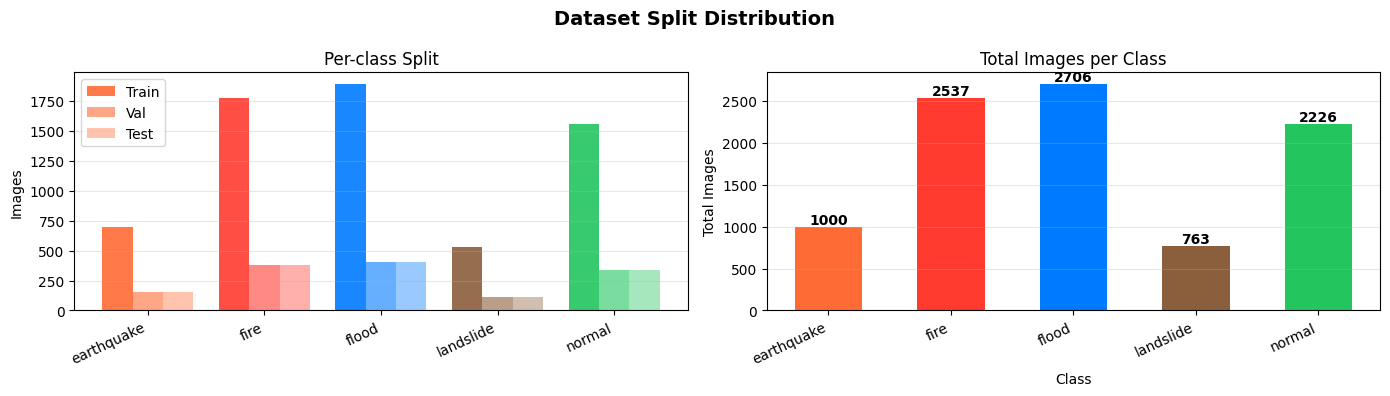

Dataset split complete.


In [4]:
def split_dataset() -> dict:
    print("Splitting dataset (70 / 15 / 15) ...\n")

    split_dirs = {
        "train": os.path.join(SPLIT_DIR, "train"),
        "val":   os.path.join(SPLIT_DIR, "val"),
        "test":  os.path.join(SPLIT_DIR, "test"),
    }

    if all(os.path.exists(p) for p in split_dirs.values()):
        print("  → Split already exists — skipping copy step.")
        return split_dirs

    for split_path in split_dirs.values():
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(split_path, cls), exist_ok=True)

    for cls in CLASS_NAMES:
        cls_src = os.path.join(DATASET_DIR, cls)
        if not os.path.isdir(cls_src):
            print(f"Missing folder — skipping: {cls_src}")
            continue
        images = sorted([
            f for f in os.listdir(cls_src)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        if len(images) == 0:
            print(f"No images in {cls_src}")
            continue
        train_imgs, temp    = train_test_split(
            images, test_size=(1 - TRAIN_RATIO), random_state=SEED)
        val_imgs, test_imgs = train_test_split(
            temp, test_size=0.5, random_state=SEED)
        for split_name, split_imgs in [
            ("train", train_imgs), ("val", val_imgs), ("test", test_imgs)
        ]:
            for img_file in split_imgs:
                shutil.copy2(
                    os.path.join(cls_src, img_file),
                    os.path.join(split_dirs[split_name], cls, img_file)
                )
        print(f"  {cls:12s} → {len(train_imgs):4d} train | "
              f"{len(val_imgs):3d} val | {len(test_imgs):3d} test")
    return split_dirs

split_dirs = split_dataset()

# ----- Summary table -----
print()
print("-" * 52)
split_counts = {}
total_train = total_val = total_test = 0
for cls in CLASS_NAMES:
    tr = len(os.listdir(os.path.join(split_dirs["train"], cls)))
    va = len(os.listdir(os.path.join(split_dirs["val"],   cls)))
    te = len(os.listdir(os.path.join(split_dirs["test"],  cls)))
    split_counts[cls] = (tr, va, te)
    total_train += tr; total_val += va; total_test += te

print(f"  {'Class':12s} {'Train':>6} {'Val':>5} {'Test':>5} {'Total':>6}")
print("  " + "-" * 38)
for cls, (tr, va, te) in split_counts.items():
    print(f"  {cls:12s} {tr:6d} {va:5d} {te:5d} {tr+va+te:6d}")
print("  " + "-" * 38)
print(f"  {'TOTAL':12s} {total_train:6d} {total_val:5d} {total_test:5d} "
      f"{total_train+total_val+total_test:6d}")
print("-" * 52)

# ----- Bar chart -----
COLORS = {"earthquake":"#FF6B35","fire":"#FF3B30","flood":"#007AFF",
          "landslide":"#8B5E3C","normal":"#22C55E"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Dataset Split Distribution", fontsize=14, fontweight='bold')

trains = [split_counts[c][0] for c in CLASS_NAMES]
vals   = [split_counts[c][1] for c in CLASS_NAMES]
tests  = [split_counts[c][2] for c in CLASS_NAMES]
colors = [COLORS[c] for c in CLASS_NAMES]
x      = np.arange(len(CLASS_NAMES))
w      = 0.26

axes[0].bar(x - w, trains, w, label='Train', color=colors, alpha=0.9)
axes[0].bar(x,     vals,   w, label='Val',   color=colors, alpha=0.6)
axes[0].bar(x + w, tests,  w, label='Test',  color=colors, alpha=0.4)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
axes[0].set_ylabel('Images'); axes[0].set_title('Per-class Split')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

totals = [sum(split_counts[c]) for c in CLASS_NAMES]
bars   = axes[1].bar(CLASS_NAMES, totals, color=colors, edgecolor='none', width=0.55)
for b, v in zip(bars, totals):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Total Images')
axes[1].set_title('Total Images per Class')
axes[1].set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Dataset split complete.")

In [5]:
def create_generators(split_dirs: dict):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        zoom_range=0.20,
        horizontal_flip=True,
        brightness_range=[0.80, 1.20],
        fill_mode='nearest'
    )
    eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    common_args = dict(
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
    )
    train_gen = train_datagen.flow_from_directory(
        split_dirs["train"], shuffle=True,  **common_args)
    val_gen   = eval_datagen.flow_from_directory(
        split_dirs["val"],   shuffle=False, **common_args)
    test_gen  = eval_datagen.flow_from_directory(
        split_dirs["test"],  shuffle=False, **common_args)
    return train_gen, val_gen, test_gen


train_gen, val_gen, test_gen = create_generators(split_dirs)

# ----- Summary -----
print("Data generators ready.\n")
print("=" * 52)
print(f"  {'Split':<10} {'Images':>8}  {'Batches':>8}  {'Augmented':>10}")
print("  " + "-" * 42)
for gen, name, aug in [
    (train_gen, "Train", "Yes"),
    (val_gen,   "Val",   "No"),
    (test_gen,  "Test",  "No"),
]:
    batches = int(np.ceil(gen.samples / BATCH_SIZE))
    print(f"  {name:<10} {gen.samples:>8,}  {batches:>8}  {aug:>10}")
print("=" * 52)

print("\n  Class index mapping:")
print("  " + "-" * 30)
for cls, idx in sorted(train_gen.class_indices.items(), key=lambda x: x[1]):
    print(f"    [{idx}]  {cls}")
print("  " + "-" * 30)

print(f"\n  Input batch shape : {train_gen[0][0].shape}")
print(f"  Label batch shape : {train_gen[0][1].shape}")
print("\nGenerators created.")

Found 6460 images belonging to 5 classes.
Found 1385 images belonging to 5 classes.
Found 1387 images belonging to 5 classes.
Data generators ready.

  Split        Images   Batches   Augmented
  ------------------------------------------
  Train         6,460       404         Yes
  Val           1,385        87          No
  Test          1,387        87          No

  Class index mapping:
  ------------------------------
    [0]  earthquake
    [1]  fire
    [2]  flood
    [3]  landslide
    [4]  normal
  ------------------------------

  Input batch shape : (16, 224, 224, 3)
  Label batch shape : (16, 5)

Generators created.


In [6]:
def build_model():
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    x       = base.output
    x       = GlobalAveragePooling2D()(x)
    x       = BatchNormalization()(x)
    x       = Dense(256, activation='relu')(x)
    x       = Dropout(0.40)(x)
    x       = Dense(128, activation='relu')(x)
    x       = Dropout(0.30)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base


model, base = build_model()

# ----- Parameter summary -----
total      = sum(np.prod(w.shape) for w in model.weights)
trainable  = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen     = total - trainable

print("EfficientNetB0 model built.\n")
print("=" * 52)
print("  Parameter Summary")
print("  " + "-" * 42)
print(f"  Total params      : {total:>12,.0f}")
print(f"  Trainable (head)  : {trainable:>12,.0f}")
print(f"  Frozen (base)     : {frozen:>12,.0f}")
print("=" * 52)

# ----- Architecture layers (custom head only) -----
print("\n  Custom Head Architecture:")
print("  " + "-" * 42)
head_types = ['GlobalAveragePooling2D','BatchNormalization','Dense','Dropout']
for layer in model.layers:
    ltype = type(layer).__name__
    if ltype in head_types:
        cfg   = layer.get_config()
        extra = ""
        if ltype == "Dense":
            extra = f" · units={cfg['units']} · activation={cfg['activation']}"
        elif ltype == "Dropout":
            extra = f" · rate={cfg['rate']}"
        print(f"    {ltype}{extra}")
print("  " + "-" * 42)
print(f"  Output: Softmax({NUM_CLASSES} classes)")
print("\nModel ready for training.")

EfficientNetB0 model built.

  Parameter Summary
  ------------------------------------------
  Total params      :    4,416,168
  Trainable (head)  :      364,037
  Frozen (base)     :    4,052,131

  Custom Head Architecture:
  ------------------------------------------
    BatchNormalization
    BatchNormalization
    GlobalAveragePooling2D
    BatchNormalization
    BatchNormalization
    BatchNormalization
    GlobalAveragePooling2D
    BatchNormalization
    BatchNormalization
    BatchNormalization
    GlobalAveragePooling2D
    BatchNormalization
    Dropout · rate=0.025
    BatchNormalization
    BatchNormalization
    GlobalAveragePooling2D
    BatchNormalization
    BatchNormalization
    BatchNormalization
    GlobalAveragePooling2D
    BatchNormalization
    Dropout · rate=0.05
    BatchNormalization
    BatchNormalization
    GlobalAveragePooling2D
    BatchNormalization
    BatchNormalization
    BatchNormalization
    GlobalAveragePooling2D
    BatchNormalization
    Dr

Class weights computed.

  Class         Train Images   Weight
  --------------------------------------
  earthquake             699   1.8484  ██████████████████
  fire                 1,775   0.7279  ███████
  flood                1,894   0.6822  ██████
  landslide              534   2.4195  ████████████████████████
  normal               1,558   0.8293  ████████
  Weight > 1.0 → underrepresented class (gets more attention)
  Weight < 1.0 → overrepresented class  (gets less attention)


C:\Users\Princess Lyn\AppData\Local\Temp\ipykernel_1844\1858945368.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=25, ha='right')
C:\Users\Princess Lyn\AppData\Local\Temp\ipykernel_1844\1858945368.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=25, ha='right')


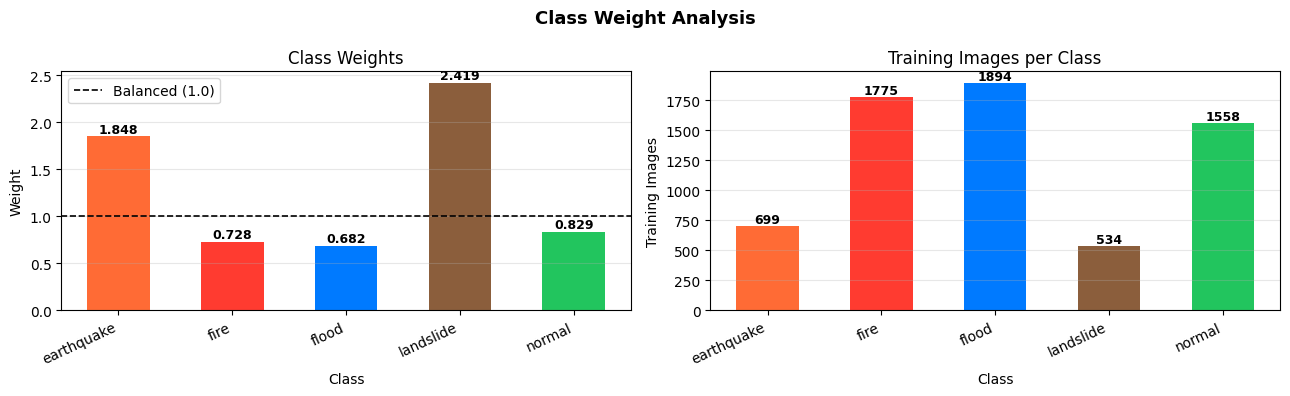


Class weights ready.


In [7]:
def compute_weights(train_gen) -> dict:
    labels         = train_gen.classes
    unique_classes = np.unique(labels)
    weights        = compute_class_weight(
        class_weight='balanced', classes=unique_classes, y=labels)
    cw             = dict(zip(unique_classes, weights))
    return cw


class_weights  = compute_weights(train_gen)
idx_to_name    = {v: k for k, v in train_gen.class_indices.items()}
counts_per_cls = {idx_to_name[i]: np.sum(train_gen.classes == i)
                  for i in class_weights}

print("Class weights computed.\n")
print("=" * 52)
print(f"  {'Class':12s} {'Train Images':>13} {'Weight':>8}")
print("  " + "-" * 38)
for idx, w in sorted(class_weights.items()):
    name  = idx_to_name.get(idx, f"class_{idx}")
    count = counts_per_cls[name]
    bar   = "█" * int(w * 10)
    print(f"  {name:12s} {count:>13,} {w:>8.4f}  {bar}")
print("=" * 52)
print("  Weight > 1.0 → underrepresented class (gets more attention)")
print("  Weight < 1.0 → overrepresented class  (gets less attention)")

# ----- Bar chart -----
names   = [idx_to_name[i] for i in sorted(class_weights)]
wts     = [class_weights[i] for i in sorted(class_weights)]
colors  = [COLORS.get(n, "#888") for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Class Weight Analysis", fontsize=13, fontweight='bold')

bars = axes[0].bar(names, wts, color=colors, edgecolor='none', width=0.55)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Balanced (1.0)')
for b, v in zip(bars, wts):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f"{v:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Weight')
axes[0].set_title('Class Weights'); axes[0].legend()
axes[0].set_xticklabels(names, rotation=25, ha='right')
axes[0].grid(axis='y', alpha=0.3)

cnts   = [counts_per_cls[n] for n in names]
bars2  = axes[1].bar(names, cnts, color=colors, edgecolor='none', width=0.55)
for b, v in zip(bars2, cnts):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Training Images')
axes[1].set_title('Training Images per Class')
axes[1].set_xticklabels(names, rotation=25, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("\nClass weights ready.")

Training — Phase 1 (head only, base frozen)
Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.7232 - loss: 0.8731
Epoch 1: val_accuracy improved from None to 0.91119, saving model to models\disaster_classifier.keras

Epoch 1: finished saving model to models\disaster_classifier.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.7929 - loss: 0.7002 - val_accuracy: 0.9112 - val_loss: 0.2626 - learning_rate: 0.0010
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.8726 - loss: 0.4330
Epoch 2: val_accuracy did not improve from 0.91119
404/404 ━━━━━━━━━━━━━━━━━━━━ 263s 651ms/step - accuracy: 0.8598 - loss: 0.4681 - val_accuracy: 0.8989 - val_loss: 0.2737 - learning_rate: 0.0010
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8660 - loss: 0.4279
Epoch 3: val_accuracy improved from 0.91119 to 0.92635, saving model to models\disaster_classifier.keras

Epoch 3: finished saving model to models\disaster_classifier.keras
404/404 ━━━

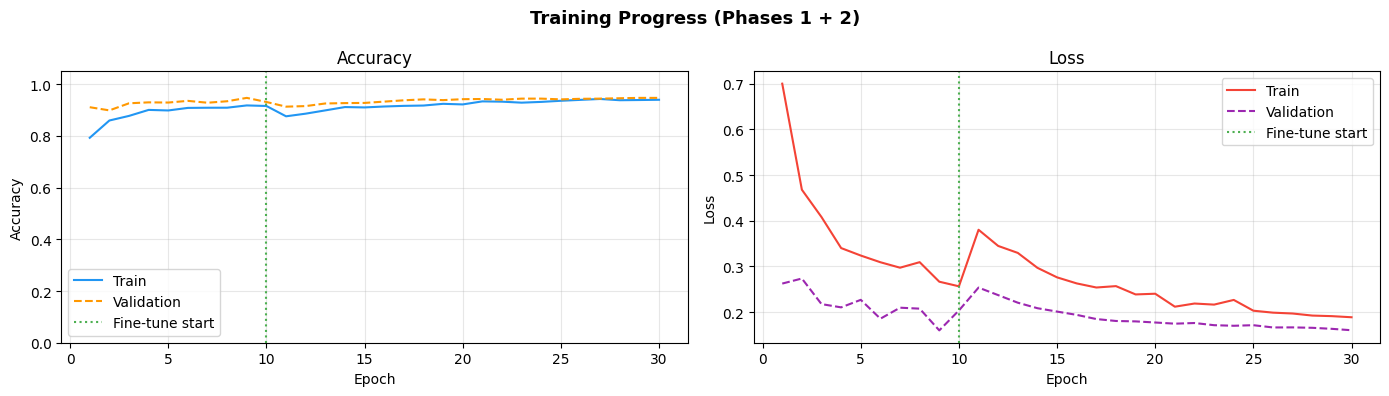


  Training complete.
    Best val_accuracy : 0.9473
    Model saved       : d:\Disaster\models\disaster_classifier.keras
    Curves saved      : d:\Disaster\eval\training_curves.png


In [8]:
def train(model, base, train_gen, val_gen, class_weights: dict) -> dict:
    def get_callbacks():
        return [
            EarlyStopping(monitor='val_loss', patience=5,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                              patience=3, min_lr=1e-8, verbose=1),
            ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                            save_best_only=True, verbose=1),
        ]

    # ----- Phase 1: Head only -----
    print("Training — Phase 1 (head only, base frozen)")
    print("=" * 52)
    h1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS_FROZEN,
        class_weight=class_weights,
        callbacks=get_callbacks(), verbose=1
    )

    p1_acc = max(h1.history['val_accuracy'])
    print(f"\n  Phase 1 best val_accuracy : {p1_acc:.4f}")

    # ----- Phase 2: Fine-tune last 20 base layers -----
    print("\nTraining — Phase 2 (fine-tuning last 20 layers)")
    print("=" * 52)
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    h2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS_FINETUNE,
        class_weight=class_weights,
        callbacks=get_callbacks(), verbose=1
    )

    p2_acc = max(h2.history['val_accuracy'])
    print(f"\n  Phase 2 best val_accuracy : {p2_acc:.4f}")

    combined = {k: h1.history[k] + h2.history[k] for k in h1.history}

    # ── Live training curve ───────────────────────────────────
    epochs = range(1, len(combined['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle("Training Progress (Phases 1 + 2)", fontsize=13, fontweight='bold')

    axes[0].plot(epochs, combined['accuracy'],     '#2196F3', label='Train')
    axes[0].plot(epochs, combined['val_accuracy'], '#FF9800', label='Validation',
                 linestyle='--')
    axes[0].axvline(EPOCHS_FROZEN, color='#4CAF50', linestyle=':',
                    linewidth=1.5, label='Fine-tune start')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend()
    axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

    axes[1].plot(epochs, combined['loss'],     '#F44336', label='Train')
    axes[1].plot(epochs, combined['val_loss'], '#9C27B0', label='Validation',
                 linestyle='--')
    axes[1].axvline(EPOCHS_FROZEN, color='#4CAF50', linestyle=':',
                    linewidth=1.5, label='Fine-tune start')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    curves_path = os.path.join(EVAL_DIR, "training_curves.png")
    plt.savefig(curves_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"\n  Training complete.")
    print(f"    Best val_accuracy : {max(combined['val_accuracy']):.4f}")
    print(f"    Model saved       : {os.path.abspath(MODEL_PATH)}")
    print(f"    Curves saved      : {os.path.abspath(curves_path)}")

    return combined


# ── Run ───────────────────────────────────────────────────────
history = train(model, base, train_gen, val_gen, class_weights)

Evaluating on test set ...

  Test Set Results
  ------------------------------------------
  Accuracy  :   96.40%
  Loss      :  0.1057
  Precision :   96.40%  (weighted avg)
  Recall    :   96.40%  (weighted avg)
  F1-Score  :   96.39%  (weighted avg)

  Per-class Breakdown:
  Class         Precision   Recall       F1   Support
  ----------------------------------------------------
  earthquake        92.9%    96.0%    94.5%       151
  fire              97.9%    99.2%    98.6%       381
  flood             97.8%    97.0%    97.4%       406
  landslide         92.0%    90.4%    91.2%       115
  normal            96.0%    94.6%    95.3%       334
  ----------------------------------------------------
  Weighted Avg      96.4%    96.4%    96.4%

  Metrics saved → d:\Disaster\eval\metrics.json


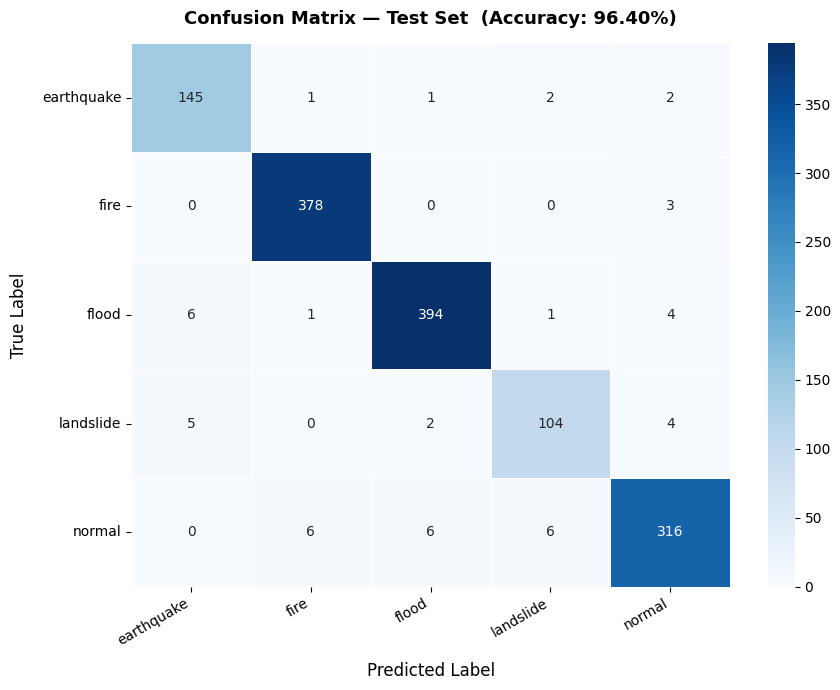

  Confusion matrix saved → d:\Disaster\eval\confusion_matrix.png


C:\Users\Princess Lyn\AppData\Local\Temp\ipykernel_1844\1033482667.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')


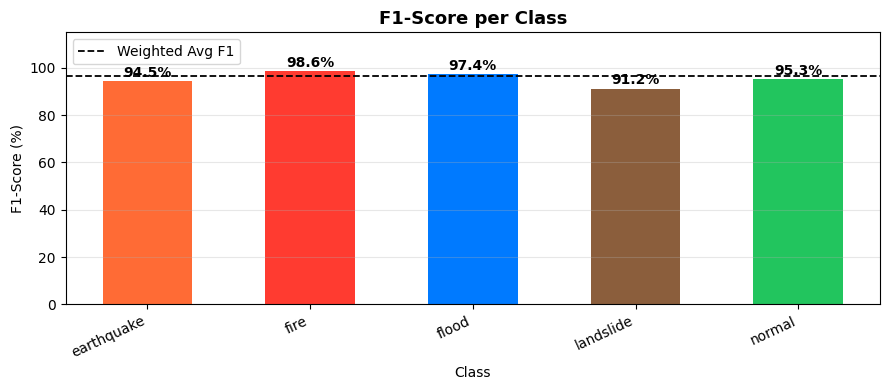


Evaluation complete.


In [9]:
def evaluate(model, test_gen, history: dict):
    print("Evaluating on test set ...\n")

    # ----- Test metrics -----
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)

    y_probs = model.predict(test_gen, verbose=0)
    y_pred  = np.argmax(y_probs, axis=1)
    y_true  = test_gen.classes

    report_str  = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    report_dict = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

    # ----- Print results -----
    wr = report_dict.get("weighted avg", {})
    print("=" * 52)
    print("  Test Set Results")
    print("  " + "-" * 42)
    print(f"  Accuracy  : {test_acc*100:>7.2f}%")
    print(f"  Loss      : {test_loss:>7.4f}")
    print(f"  Precision : {wr.get('precision',0)*100:>7.2f}%  (weighted avg)")
    print(f"  Recall    : {wr.get('recall',0)*100:>7.2f}%  (weighted avg)")
    print(f"  F1-Score  : {wr.get('f1-score',0)*100:>7.2f}%  (weighted avg)")
    print("=" * 52)

    print("\n  Per-class Breakdown:")
    print(f"  {'Class':12s} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
    print("  " + "-" * 52)
    for cls in CLASS_NAMES:
        r = report_dict.get(cls, {})
        print(f"  {cls:12s} {r.get('precision',0)*100:>9.1f}% "
              f"{r.get('recall',0)*100:>7.1f}% "
              f"{r.get('f1-score',0)*100:>7.1f}% "
              f"{int(r.get('support',0)):>9}")
    print("  " + "-" * 52)
    print(f"  {'Weighted Avg':12s} {wr.get('precision',0)*100:>9.1f}% "
          f"{wr.get('recall',0)*100:>7.1f}% "
          f"{wr.get('f1-score',0)*100:>7.1f}%")

    metrics = {
        "test_accuracy":         float(test_acc),
        "test_loss":             float(test_loss),
        "classification_report": report_dict,
        "class_names":           CLASS_NAMES,
    }
    metrics_path = os.path.join(EVAL_DIR, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)
    print(f"\n  Metrics saved → {os.path.abspath(metrics_path)}")

    # ----- Confusion matrix -----
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
    ax.set_ylabel("True Label",      fontsize=12, labelpad=10)
    ax.set_title(f"Confusion Matrix — Test Set  (Accuracy: {test_acc*100:.2f}%)",
                 fontsize=13, fontweight='bold', pad=14)
    plt.xticks(rotation=30, ha='right', fontsize=10)
    plt.yticks(rotation=0,  fontsize=10)
    plt.tight_layout()
    cm_path = os.path.join(EVAL_DIR, "confusion_matrix.png")
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Confusion matrix saved → {os.path.abspath(cm_path)}")

    # ----- F1 bar chart per class -----
    f1_scores = [report_dict.get(c, {}).get('f1-score', 0) * 100
                 for c in CLASS_NAMES]
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(CLASS_NAMES,
                  f1_scores,
                  color=[COLORS.get(c, '#888') for c in CLASS_NAMES],
                  edgecolor='none', width=0.55)
    for b, v in zip(bars, f1_scores):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                f"{v:.1f}%", ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.axhline(wr.get('f1-score', 0) * 100, color='black',
               linestyle='--', linewidth=1.3, label=f"Weighted Avg F1")
    ax.set_xlabel('Class'); ax.set_ylabel('F1-Score (%)')
    ax.set_title('F1-Score per Class', fontsize=13, fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
    ax.set_ylim(0, 115); ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

    print("\nEvaluation complete.")


evaluate(model, test_gen, history)

In [10]:
print("=" * 52)
print("Training Pipeline Complete!")
print("=" * 52)

outputs = [
    ("Trained model",     MODEL_PATH),
    ("Confusion matrix",  os.path.join(EVAL_DIR, "confusion_matrix.png")),
    ("Training curves",   os.path.join(EVAL_DIR, "training_curves.png")),
    ("Metrics (JSON)",    os.path.join(EVAL_DIR, "metrics.json")),
]

print("\n  Output files:")
print("  " + "-" * 48)
for label, path in outputs:
    exists = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"  {exists}  {label:<20} {path}")

print("\n  Next step — launch the dashboard:")
print("    streamlit run app.py")
print("=" * 52)

Training Pipeline Complete!

  Output files:
  ------------------------------------------------
  ✅  Trained model        models\disaster_classifier.keras
  ✅  Confusion matrix     eval\confusion_matrix.png
  ✅  Training curves      eval\training_curves.png
  ✅  Metrics (JSON)       eval\metrics.json

  Next step — launch the dashboard:
    streamlit run app.py
